# Данные

In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
ds = load_dataset("SetFit/ag_news")

train = ds["train"].to_pandas().copy()
test = ds["test"].to_pandas().copy()

test_2000, _ = train_test_split(
    test,
    train_size=2000,
    stratify=test["label"],
    random_state=42,
    shuffle=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
train.isna().sum()

,0
text,0
label,0
label_text,0


In [ ]:
test.isna().sum()

,0
text,0
label,0
label_text,0


In [ ]:
train

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports


In [ ]:
test_2000

,text,label,label_text
17,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech
5460,Federated Department Stores Posts Profit NEW ...,2,Business
3264,CA aquires computer security firm Computer Ass...,2,Business
2945,Molson issues earnings warning MONTREAL - Mols...,2,Business
1184,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports
...,...,...,...
6393,Nintendo Returns to Profit (AP) AP - Nintendo ...,3,Sci/Tech
7568,"Democrat Seeks to End Iowa, N.H. Power (AP) AP...",0,World
6677,Pinault-Printemps Redoute to sell holding in R...,2,Business
4535,NASCAR mourns plane crash victims Crews on all...,1,Sports


# Илья (тема 6)

## подготовка данных и вспомогательных ф-й / переменных

In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from openai import OpenAI
from tqdm.auto import tqdm
import json
import time
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [ ]:
ds = load_dataset("SetFit/ag_news")

train = ds["train"].to_pandas().copy()
test = ds["test"].to_pandas().copy()

test_2000, _ = train_test_split(
    test,
    train_size=2000,
    stratify=test["label"],
    random_state=42,
    shuffle=True
)

test_2000 = test_2000.reset_index(drop=True)

In [ ]:
train

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports


In [ ]:
test_2000

,text,label,label_text
0,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech
1,Federated Department Stores Posts Profit NEW ...,2,Business
2,CA aquires computer security firm Computer Ass...,2,Business
3,Molson issues earnings warning MONTREAL - Mols...,2,Business
4,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports
...,...,...,...
1995,Nintendo Returns to Profit (AP) AP - Nintendo ...,3,Sci/Tech
1996,"Democrat Seeks to End Iowa, N.H. Power (AP) AP...",0,World
1997,Pinault-Printemps Redoute to sell holding in R...,2,Business
1998,NASCAR mourns plane crash victims Crews on all...,1,Sports


In [ ]:
with open("api_key.txt", "r") as f:
    API_KEY = f.read().strip()

client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.deepseek.com"
)

In [ ]:
LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [ ]:
CLASS_DESCRIPTION = """
You are classifying news articles from the AG News dataset.

There are exactly four classes:

0 = World
News about international events, politics, governments, diplomacy, wars, conflicts, elections, global crises, and world affairs.

1 = Sports
News about sports, athletes, teams, matches, tournaments, scores, coaches, leagues, and sporting events.

2 = Business
News about companies, markets, stocks, finance, economy, trade, industries, oil prices, corporate earnings, mergers, and business activity.

3 = Sci/Tech
News about science, technology, software, hardware, internet, space, medicine, research, gadgets, cybersecurity, and technical innovation.
"""

In [ ]:
def extract_json_array(text):
    """
    Достаёт JSON-массив из ответа модели.
    Ожидаем что-то вроде: [0, 1, 2, 3]
    """
    text = text.strip()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass

    match = re.search(r"\[[\s\S]*?\]", text)
    if match:
        return json.loads(match.group(0))

    raise ValueError(f"Could not parse JSON array from response: {text}")

In [ ]:
def validate_predictions(preds, expected_len):
    """
    Проверяем, что модель вернула нужное количество меток
    и что все метки принадлежат множеству {0, 1, 2, 3}.
    """
    if not isinstance(preds, list):
        raise ValueError("Predictions are not a list")

    if len(preds) != expected_len:
        raise ValueError(f"Expected {expected_len} predictions, got {len(preds)}")

    preds = [int(x) for x in preds]

    for p in preds:
        if p not in [0, 1, 2, 3]:
            raise ValueError(f"Invalid label: {p}")

    return preds

In [ ]:
def call_deepseek_batch(system_msg, user_prompt, batch_size, max_retries=5):
    """
    Один батчевый запрос к DeepSeek.
    Возвращает список предсказанных классов.
    """
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model="deepseek-chat",
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=0.0,
                max_tokens=300,
            )

            content = resp.choices[0].message.content
            preds = extract_json_array(content)
            preds = validate_predictions(preds, batch_size)
            return preds

        except Exception as e:
            wait_time = 2 ** attempt
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(wait_time)

    raise RuntimeError("All retries failed")

In [ ]:
def make_batch_prompt(texts):
    """
    Формирует prompt для батча текстов.
    """
    items = []

    for i, text in enumerate(texts):
        items.append(f"{i}. {text}")

    joined_items = "\n\n".join(items)

    prompt = f"""
Classify each news article below into exactly one of the following labels:

0 = World
1 = Sports
2 = Business
3 = Sci/Tech

Return only a valid JSON array of integers.
The array must contain exactly {len(texts)} items.
Do not include explanations, markdown, comments, or extra text.

Articles:

{joined_items}
"""

    return prompt

In [ ]:
def classify_dataframe_zero_shot(df, text_col="text", batch_size=20):
    """
    Zero-shot классификация.
    train не используется.
    """
    system_msg = f"""
You are a precise text classification model.

{CLASS_DESCRIPTION}

Your task is to classify each input news article.
Return only class IDs: 0, 1, 2, or 3.
Do not explain your answer.
"""

    all_preds = []

    for start in tqdm(range(0, len(df), batch_size)):
        batch_texts = df[text_col].iloc[start:start + batch_size].tolist()
        prompt = make_batch_prompt(batch_texts)

        preds = call_deepseek_batch(
            system_msg=system_msg,
            user_prompt=prompt,
            batch_size=len(batch_texts)
        )

        all_preds.extend(preds)

    return all_preds

## zero-shot model

In [ ]:
zero_shot_preds = classify_dataframe_zero_shot(
    df=test_2000,
    text_col="text",
    batch_size=20
)

test_2000["pred_zero_shot"] = zero_shot_preds

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
test_2000[["text", "label", "label_text", "pred_zero_shot"]].head()

,text,label,label_text,pred_zero_shot
0,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech,3
1,Federated Department Stores Posts Profit NEW ...,2,Business,2
2,CA aquires computer security firm Computer Ass...,2,Business,3
3,Molson issues earnings warning MONTREAL - Mols...,2,Business,2
4,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports,1


In [ ]:
zero_shot_accuracy = (test_2000["label"] == test_2000["pred_zero_shot"]).mean()
zero_shot_accuracy

np.float64(0.845)

In [ ]:
test_2000.to_csv("ag_news_test_2000_zero_shot.csv", index=False)

## Few-shot модель

In [ ]:
def sample_few_shot_examples(train_df, examples_per_class=3, random_state=42):
    """
    Берём случайные few-shot примеры из train.
    По examples_per_class примеров на каждый класс.
    """
    examples = []

    for label in sorted(train_df["label"].unique()):
        part = train_df[train_df["label"] == label].sample(
            n=examples_per_class,
            random_state=random_state
        )

        for _, row in part.iterrows():
            examples.append({
                "text": row["text"],
                "label": int(row["label"]),
                "label_text": row["label_text"]
            })

    return examples

In [ ]:
few_shot_examples = sample_few_shot_examples(
    train_df=train,
    examples_per_class=3,
    random_state=42
)

few_shot_examples

[{'text': 'Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.',
  'label': 0,
  'label_text': 'World'},
 {'text': "BBC reporters' log BBC correspondents record events in the Middle East and their thoughts as the funeral of the Palestinian leader Yasser Arafat takes place.",
  'label': 0,
  'label_text': 'World'},
 {'text': 'Israel welcomes Rice nomination; Palestinians wary Israel on Tuesday warmly welcomed the naming of Condoleezza Rice as America #39;s top diplomat, but Palestinians were wary, saying the new Bush administration must put more energy into the quest for Middle East peace.',
  'label': 0,
  'label_text': 'World'},
 {'text': 'Second Andre win in a row boosts US gold medal hopes Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United Sta

In [ ]:
def format_few_shot_examples(examples):
    formatted = []

    for i, ex in enumerate(examples, start=1):
        formatted.append(
            f"""Example {i}
Text: {ex["text"]}
Label: {ex["label"]}"""
        )

    return "\n\n".join(formatted)

In [ ]:
FEW_SHOT_BLOCK = format_few_shot_examples(few_shot_examples)

print(FEW_SHOT_BLOCK)

Example 1
Text: Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.
Label: 0

Example 2
Text: BBC reporters' log BBC correspondents record events in the Middle East and their thoughts as the funeral of the Palestinian leader Yasser Arafat takes place.
Label: 0

Example 3
Text: Israel welcomes Rice nomination; Palestinians wary Israel on Tuesday warmly welcomed the naming of Condoleezza Rice as America #39;s top diplomat, but Palestinians were wary, saying the new Bush administration must put more energy into the quest for Middle East peace.
Label: 0

Example 4
Text: Second Andre win in a row boosts US gold medal hopes Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday by narrowly beating Cuba #39;s Y

In [ ]:
from collections import Counter

print("Total few-shot examples:", len(few_shot_examples))
print("Examples by class:", Counter([ex["label"] for ex in few_shot_examples]))

Total few-shot examples: 12
Examples by class: Counter({0: 3, 1: 3, 2: 3, 3: 3})


In [ ]:
def make_batch_prompt(texts):
    items = []

    for i, text in enumerate(texts):
        items.append(f"Article {i}\nText: {text}")

    joined_items = "\n\n".join(items)

    prompt = f"""
Classify each news article below into exactly one class.

Classes:
0 = World
1 = Sports
2 = Business
3 = Sci/Tech

There are exactly {len(texts)} articles.
They are numbered from 0 to {len(texts) - 1}.

Return only a valid JSON array of integers.
The JSON array must contain exactly {len(texts)} integers.
The first integer must be the label for Article 0.
The second integer must be the label for Article 1.
Continue in the same order.

Do not skip articles.
Do not add explanations.
Do not add markdown.
Do not add text before or after the JSON array.

Articles:

{joined_items}
"""

    return prompt

In [ ]:
def extract_json_array(text):
    """
    Достаёт JSON-массив из ответа модели.
    Ожидаем что-то вроде: [0, 1, 2, 3]
    """
    text = text.strip()

    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass

    match = re.search(r"\[[\s\S]*?\]", text)
    if match:
        return json.loads(match.group(0))

    raise ValueError(f"Could not parse JSON array from response: {text}")

In [ ]:
def validate_predictions(preds, expected_len):
    """
    Проверяем, что модель вернула нужное количество меток
    и что все метки принадлежат множеству {0, 1, 2, 3}.
    """
    if not isinstance(preds, list):
        raise ValueError("Predictions are not a list")

    if len(preds) != expected_len:
        raise ValueError(f"Expected {expected_len} predictions, got {len(preds)}")

    preds = [int(x) for x in preds]

    for p in preds:
        if p not in [0, 1, 2, 3]:
            raise ValueError(f"Invalid label: {p}")

    return preds

In [ ]:
def call_deepseek_batch_safe(system_msg, user_prompt, expected_len, max_retries=3):
    """
    Безопасный вызов модели.
    Если модель вернула неправильный формат или неправильное количество меток,
    функция возвращает None, а не останавливает весь пайплайн.
    """
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model="deepseek-chat",
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=0.0,
                max_tokens=200,
            )

            content = resp.choices[0].message.content
            preds = extract_json_array(content)
            preds = validate_predictions(preds, expected_len)

            return preds

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(1)

    return None

In [ ]:
def classify_single_text(system_msg, text):
    """
    Классификация одного текста.
    Используется только если батч не получилось обработать нормально.
    """
    single_prompt = f"""
Classify this news article into exactly one class.

Classes:
0 = World
1 = Sports
2 = Business
3 = Sci/Tech

Return only one integer: 0, 1, 2, or 3.

Text:
{text}
"""

    for attempt in range(5):
        try:
            resp = client.chat.completions.create(
                model="deepseek-chat",
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": single_prompt},
                ],
                temperature=0.0,
                max_tokens=20,
            )

            content = resp.choices[0].message.content.strip()
            match = re.search(r"[0-3]", content)

            if match:
                return int(match.group(0))

        except Exception as e:
            print(f"Single retry {attempt + 1} failed: {e}")
            time.sleep(1)

    raise RuntimeError("Could not classify a single text")

In [ ]:
def classify_texts_adaptive(system_msg, texts):
    """
    Пытается классифицировать список текстов одним батчем.
    Если батч ломается, делит его пополам.
    Если остался один текст, классифицирует его отдельно.
    """
    prompt = make_batch_prompt(texts)

    preds = call_deepseek_batch_safe(
        system_msg=system_msg,
        user_prompt=prompt,
        expected_len=len(texts),
        max_retries=3
    )

    if preds is not None:
        return preds

    if len(texts) == 1:
        print("Single-item batch failed. Classifying one text.")
        return [classify_single_text(system_msg, texts[0])]

    mid = len(texts) // 2

    print(f"Batch of {len(texts)} failed. Splitting into {mid} and {len(texts) - mid}.")

    left_preds = classify_texts_adaptive(system_msg, texts[:mid])
    right_preds = classify_texts_adaptive(system_msg, texts[mid:])

    return left_preds + right_preds

In [ ]:
def classify_dataframe_few_shot_stable(
    df,
    text_col="text",
    batch_size=15,
    save_path="ag_news_test_2000_few_shot_progress.csv"
):
    """
    Few-shot классификация.
    Использует уже созданные few_shot_examples и FEW_SHOT_BLOCK.
    После каждого батча сохраняет прогресс в CSV.
    """

    system_msg = f"""
You are a precise text classification model.

{CLASS_DESCRIPTION}

Below are labeled examples from the training set.

{FEW_SHOT_BLOCK}

Your task is to classify each new input news article.
Return only class IDs: 0, 1, 2, or 3.
Do not explain your answer.
"""

    result_df = df.copy()

    if "pred_few_shot" not in result_df.columns:
        result_df["pred_few_shot"] = pd.NA

    for start in tqdm(range(0, len(result_df), batch_size)):
        end = min(start + batch_size, len(result_df))

        # Если этот кусок уже посчитан, пропускаем
        if result_df.loc[start:end - 1, "pred_few_shot"].notna().all():
            continue

        batch_texts = result_df[text_col].iloc[start:end].tolist()

        preds = classify_texts_adaptive(
            system_msg=system_msg,
            texts=batch_texts
        )

        result_df.loc[start:end - 1, "pred_few_shot"] = preds

        # сохраняем прогресс после каждого батча
        result_df.to_csv(save_path, index=False)

    result_df["pred_few_shot"] = result_df["pred_few_shot"].astype(int)

    return result_df

In [ ]:
test_2000 = classify_dataframe_few_shot_stable(
    df=test_2000,
    text_col="text",
    batch_size=15,
    save_path="ag_news_test_2000_few_shot_progress.csv"
)

  0%|          | 0/134 [00:00<?, ?it/s]

In [ ]:
few_shot_accuracy = (test_2000["label"] == test_2000["pred_few_shot"]).mean()

print("Zero-shot accuracy:", zero_shot_accuracy)
print("Few-shot accuracy:", few_shot_accuracy)

Zero-shot accuracy: 0.845
Few-shot accuracy: 0.886


In [ ]:
test_2000.head()

,text,label,label_text,pred_zero_shot,pred_few_shot
0,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech,3,3
1,Federated Department Stores Posts Profit NEW ...,2,Business,2,2
2,CA aquires computer security firm Computer Ass...,2,Business,3,3
3,Molson issues earnings warning MONTREAL - Mols...,2,Business,2,2
4,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports,1,1


In [ ]:
test_2000.to_csv("ag_news_test_2000_ilya_predictions.csv", index=False)

# Метрики

In [ ]:
ilya_predictions = pd.read_csv("ag_news_test_2000_ilya_predictions.csv")

In [ ]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }

In [ ]:
zero_shot_metrics = calculate_metrics(
    y_true=ilya_predictions["label"],
    y_pred=ilya_predictions["pred_zero_shot"]
)

few_shot_metrics = calculate_metrics(
    y_true=ilya_predictions["label"],
    y_pred=ilya_predictions["pred_few_shot"]
)

In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Zero-shot",
        **zero_shot_metrics
    },
    {
        "model": "Few-shot",
        **few_shot_metrics
    }
])

metrics_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Zero-shot,0.845,0.845064,0.845,0.844795,0.845064,0.845,0.844795
1,Few-shot,0.886,0.886392,0.886,0.886044,0.886392,0.886,0.886044


In [ ]:
metrics_df_rounded = metrics_df.copy()

metric_cols = metrics_df_rounded.columns.drop("model")
metrics_df_rounded[metric_cols] = metrics_df_rounded[metric_cols].round(4)

metrics_df_rounded

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Zero-shot,0.845,0.8451,0.845,0.8448,0.8451,0.845,0.8448
1,Few-shot,0.886,0.8864,0.886,0.8860,0.8864,0.886,0.8860


In [ ]:
zero_report = classification_report(
    y_true=ilya_predictions["label"],
    y_pred=ilya_predictions["pred_zero_shot"],
    target_names=["World", "Sports", "Business", "Sci/Tech"],
    output_dict=True
)

zero_report_df = pd.DataFrame(zero_report).T
zero_report_df = zero_report_df.round(4)

zero_report_df

,precision,recall,f1-score,support
World,0.8266,0.858,0.8420,500.000
Sports,0.9343,0.938,0.9361,500.000
Business,0.7885,0.798,0.7932,500.000
Sci/Tech,0.8309,0.786,0.8078,500.000
accuracy,0.8450,0.845,0.8450,0.845
macro avg,0.8451,0.845,0.8448,2000.000
weighted avg,0.8451,0.845,0.8448,2000.000


In [ ]:
few_report = classification_report(
    y_true=ilya_predictions["label"],
    y_pred=ilya_predictions["pred_few_shot"],
    target_names=["World", "Sports", "Business", "Sci/Tech"],
    output_dict=True
)

few_report_df = pd.DataFrame(few_report).T
few_report_df = few_report_df.round(4)

few_report_df

,precision,recall,f1-score,support
World,0.8898,0.888,0.8889,500.000
Sports,0.9760,0.978,0.9770,500.000
Business,0.8170,0.848,0.8322,500.000
Sci/Tech,0.8628,0.830,0.8461,500.000
accuracy,0.8860,0.886,0.8860,0.886
macro avg,0.8864,0.886,0.8860,2000.000
weighted avg,0.8864,0.886,0.8860,2000.000


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
class_names = ["World", "Sports", "Business", "Sci/Tech"]

y_true = ilya_predictions["label"]

y_zero = ilya_predictions["pred_zero_shot"]
y_few = ilya_predictions["pred_few_shot"]

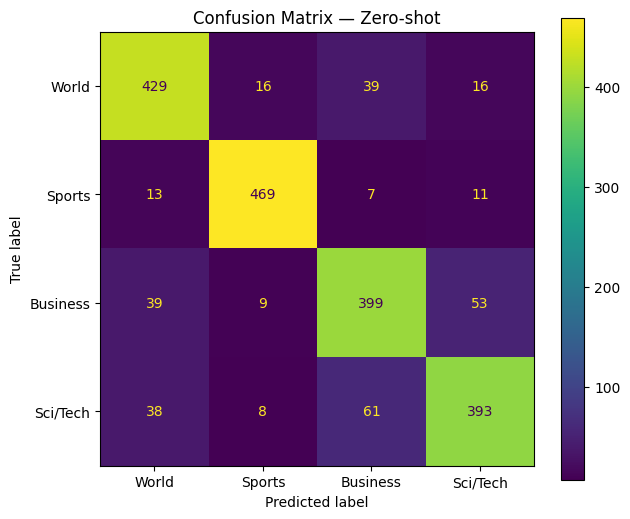

In [ ]:
cm_zero = confusion_matrix(y_true, y_zero, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_zero,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix — Zero-shot")
plt.show()

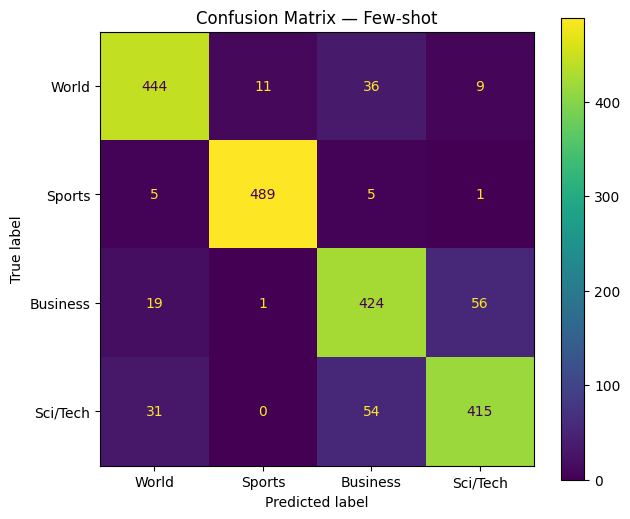

In [ ]:
cm_few = confusion_matrix(y_true, y_few, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_few,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix — Few-shot")
plt.show()